# Gráficos Combinados con Subplot y GridSpec

**Curso:** Python para Ciencia de Datos \
**Fecha:** 21 de octubre de 2025 \
**Ruta:** Fundamentos de Data Science e IA \
**Repositorio:** `bootcamp-fundamentos-ciencia-de-datos`

## 📋 Índice

1. [¿Qué son los Gráficos Combinados?](#concepto)
2. [¿Por qué usar GridSpec?](#gridspec)
3. [Sintaxis Básica](#sintaxis)
4. [Ejemplos Básicos](#ejemplos)
5. [Casos de Uso en Data Science](#casos-uso)
6. [Recursos Adicionales](#recursos)

## ¿Qué son los Gráficos Combinados?

Los **gráficos combinados** (subplots) permiten mostrar múltiples visualizaciones en una sola figura. Esto es fundamental en análisis de datos porque:

- **Comparación:** Ver múltiples perspectivas de los datos simultáneamente
- **Eficiencia:** Presentar información completa en un solo vistazo
- **Contexto:** Relacionar diferentes métricas o variables
- **Profesionalismo:** Crear dashboards y reportes ejecutivos

### ¿Cuándo usar gráficos combinados?

✅ Comparar diferentes variables del mismo dataset \
✅ Mostrar distintas visualizaciones de la misma información \
✅ Crear dashboards analíticos \
✅ Presentaciones y reportes ejecutivos \
✅ Análisis exploratorio de datos (EDA)

## ¿Por qué usar GridSpec?

**GridSpec** ofrece mayor flexibilidad que `plt.subplots()` básico:

| Característica | `plt.subplots()` | `GridSpec` |
|----------------|------------------|------------|
| Tamaños uniformes | ✅ Sí | ✅ Sí |
| Tamaños personalizados | ❌ No | ✅ Sí |
| Gráficos que ocupan múltiples celdas | ❌ Limitado | ✅ Sí |
| Control de ratios | ❌ No | ✅ Sí |
| Layouts complejos | ❌ No | ✅ Sí |

**GridSpec es ideal cuando necesitas layouts personalizados y profesionales.**

## Sintaxis Básica

### Importar las librerías necesarias

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# Configuración
plt.rcParams['figure.figsize'] = (10, 8)
print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### Estructura básica de GridSpec
```python
# Crear una cuadrícula de 2 filas x 2 columnas
gs = gridspec.GridSpec(nrows=2, ncols=2)

# Crear la figura
fig = plt.figure(figsize=(10, 8))

# Añadir subplots usando la cuadrícula
ax1 = fig.add_subplot(gs[0, 0])  # Fila 0, Columna 0
ax2 = fig.add_subplot(gs[0, 1])  # Fila 0, Columna 1
ax3 = fig.add_subplot(gs[1, :])  # Fila 1, Todas las columnas
```

### Parámetros importantes de GridSpec

- `nrows`: Número de filas
- `ncols`: Número de columnas
- `height_ratios`: Lista con proporciones de altura por fila
- `width_ratios`: Lista con proporciones de ancho por columna
- `hspace`: Espacio vertical entre subplots
- `wspace`: Espacio horizontal entre subplots

## Ejemplos Básicos

### Ejemplo 1: Grid Simple de 2x2

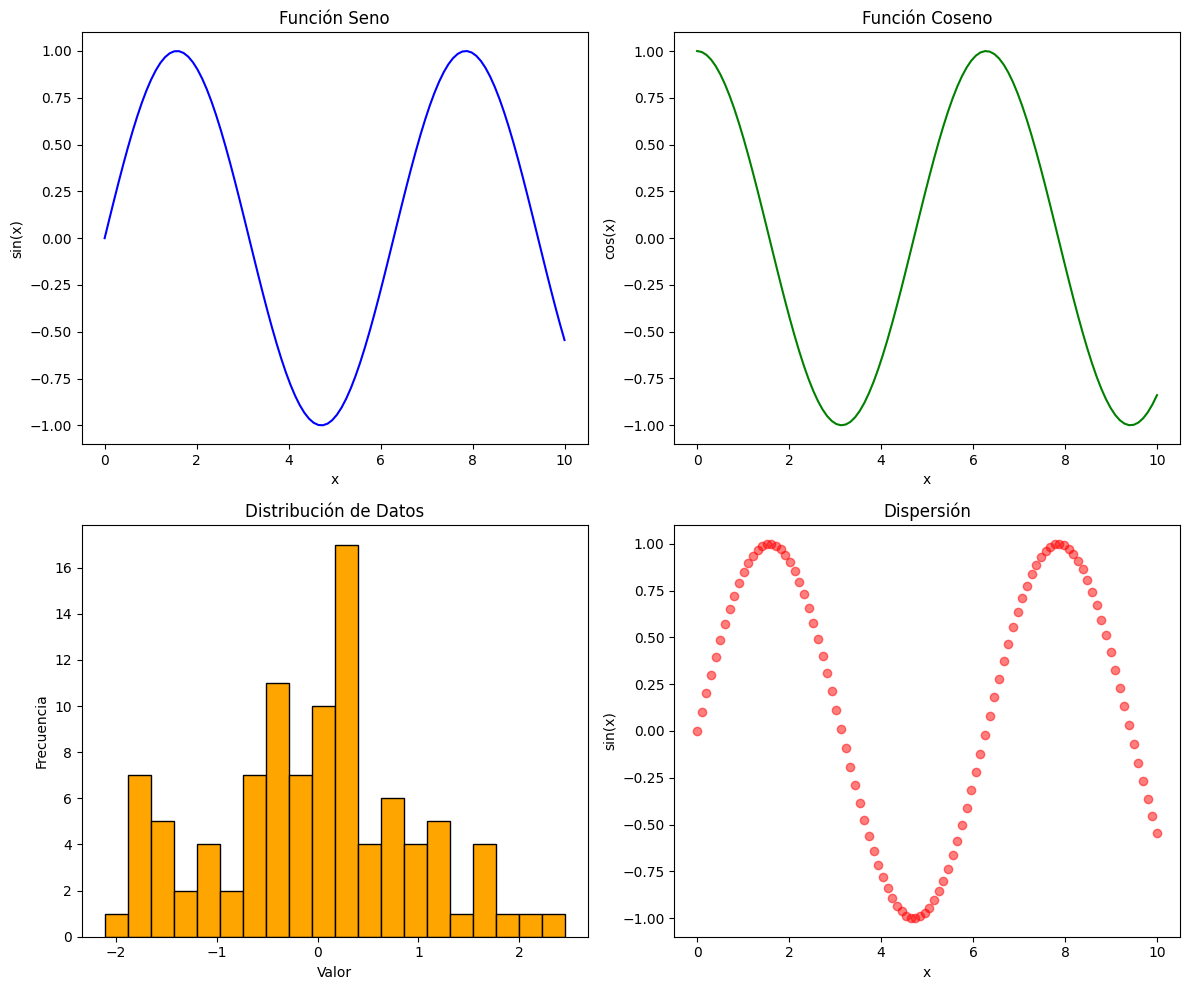

In [12]:
# Generar datos de ejemplo
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
data = np.random.randn(100)

# Crear grid simple
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Seno
axes[0, 0].plot(x, y1, color='blue')
axes[0, 0].set_title('Función Seno')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('sin(x)')

# Subplot 2: Coseno
axes[0, 1].plot(x, y2, color='green')
axes[0, 1].set_title('Función Coseno')
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('cos(x)')

# Subplot 3: Histograma
axes[1, 0].hist(data, bins=20, color='orange', edgecolor='black')
axes[1, 0].set_title('Distribución de Datos')
axes[1, 0].set_xlabel('Valor')
axes[1, 0].set_ylabel('Frecuencia')

# Subplot 4: Scatter
axes[1, 1].scatter(x, y1, color='red', alpha=0.5)
axes[1, 1].set_title('Dispersión')
axes[1, 1].set_xlabel('x')
axes[1, 1].set_ylabel('sin(x)')

plt.tight_layout()
plt.show()

### Ejemplo 2: Layout Personalizado con GridSpec

Ahora crearemos un layout más complejo donde un gráfico ocupa toda la fila superior.

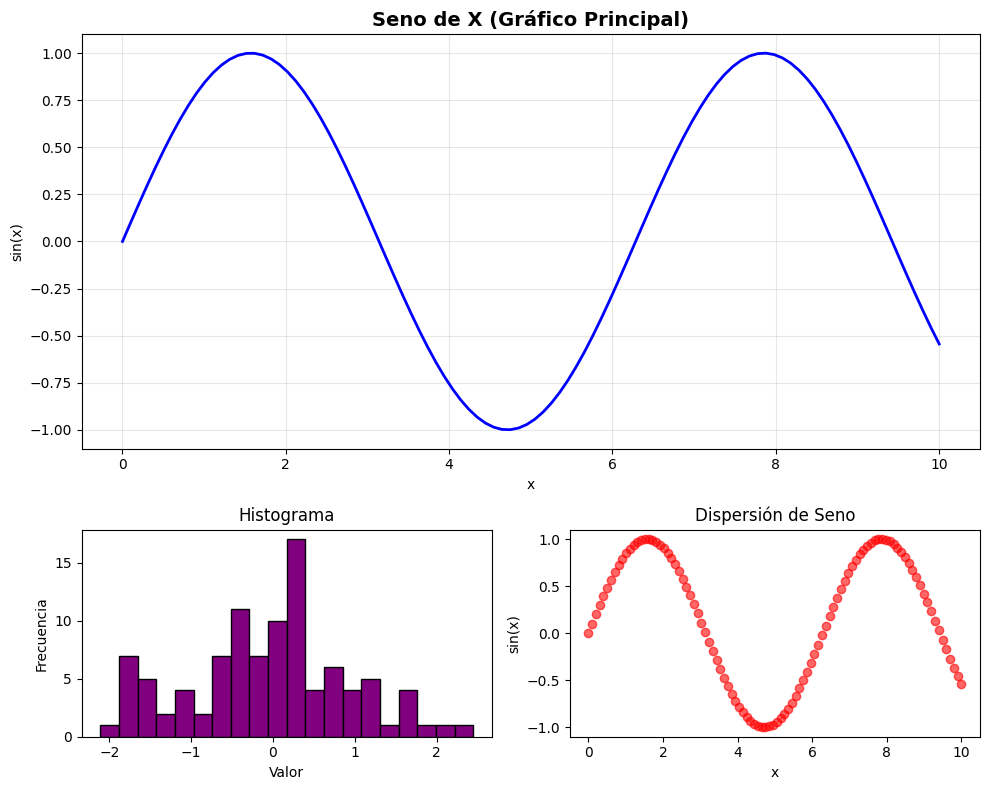

In [13]:
# Crear GridSpec con proporciones personalizadas
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[1, 1])
fig = plt.figure(figsize=(10, 8))

# Primer subplot: ocupa toda la primera fila
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x, y1, color='blue', linewidth=2)
ax1.set_title('Seno de X (Gráfico Principal)', fontsize=14, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)')
ax1.grid(True, alpha=0.3)

# Segundo subplot: esquina inferior izquierda
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(data, bins=20, color='purple', edgecolor='black')
ax2.set_title('Histograma')
ax2.set_xlabel('Valor')
ax2.set_ylabel('Frecuencia')

# Tercer subplot: esquina inferior derecha
ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(x, y1, color='red', alpha=0.6)
ax3.set_title('Dispersión de Seno')
ax3.set_xlabel('x')
ax3.set_ylabel('sin(x)')

plt.tight_layout()
plt.show()

**Nota importante:** `gs[0, :]` significa "fila 0, todas las columnas", permitiendo que el gráfico se extienda horizontalmente.

## Casos de Uso en Data Science

### Caso de Uso 1: Dashboard de Análisis de Ventas

**Contexto:** Un gerente de ventas necesita un reporte visual que muestre en una sola página:
- Tendencia de ventas mensuales
- Distribución de ventas por categoría
- Top 5 productos más vendidos

**Objetivo:** Crear un dashboard ejecutivo en una sola figura.

In [15]:
# Simular datos de ventas
np.random.seed(42)
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
ventas_mensuales = np.random.randint(50000, 150000, 12)
categorias = ['Electrónica', 'Ropa', 'Alimentos', 'Hogar', 'Deportes']
ventas_categorias = np.random.randint(20000, 80000, 5)
productos = ['Laptop', 'Smartphone', 'Tablet', 'Audífonos', 'Monitor']
ventas_productos = np.random.randint(5000, 30000, 5)
ventas_productos = np.sort(ventas_productos)[::-1]  # Ordenar descendente

print("Datos generados correctamente")
print(f"Ventas totales del año: ${ventas_mensuales.sum():,}")

Datos generados correctamente
Ventas totales del año: $1,123,211


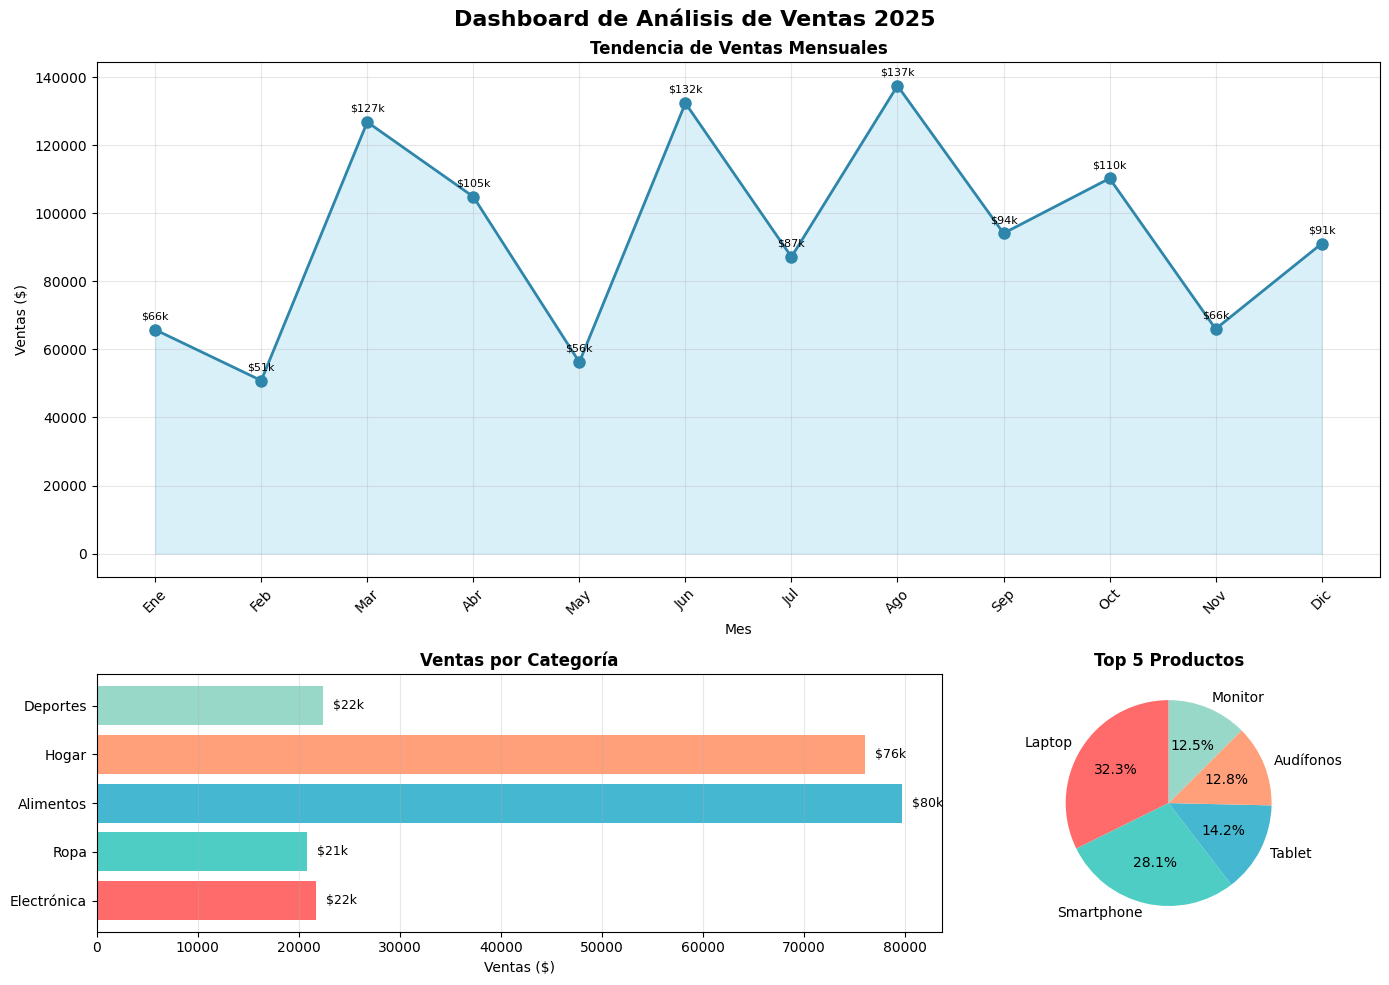

In [16]:
# Crear dashboard con GridSpec
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[2, 1])
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Dashboard de Análisis de Ventas 2025', fontsize=16, fontweight='bold')

# Gráfico 1: Tendencia de ventas mensuales (ocupa toda la fila superior)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(meses, ventas_mensuales, marker='o', linewidth=2, color='#2E86AB', markersize=8)
ax1.fill_between(range(12), ventas_mensuales, alpha=0.3, color='skyblue')
ax1.set_title('Tendencia de Ventas Mensuales', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Ventas ($)')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Añadir valores sobre los puntos
for i, v in enumerate(ventas_mensuales):
    ax1.text(i, v + 3000, f'${v/1000:.0f}k', ha='center', fontsize=8)

# Gráfico 2: Ventas por categoría (inferior izquierda)
ax2 = fig.add_subplot(gs[1, 0])
colores = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
ax2.barh(categorias, ventas_categorias, color=colores)
ax2.set_title('Ventas por Categoría', fontsize=12, fontweight='bold')
ax2.set_xlabel('Ventas ($)')
ax2.grid(True, alpha=0.3, axis='x')

# Añadir valores al final de las barras
for i, v in enumerate(ventas_categorias):
    ax2.text(v + 1000, i, f'${v/1000:.0f}k', va='center', fontsize=9)

# Gráfico 3: Top 5 productos (inferior derecha)
ax3 = fig.add_subplot(gs[1, 1])
ax3.pie(ventas_productos, labels=productos, autopct='%1.1f%%',
        startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'])
ax3.set_title('Top 5 Productos', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insights del Caso 1:**

✅ **Vista completa:** El gerente puede ver 3 perspectivas diferentes en una sola imagen
✅ **Tendencias claras:** La línea temporal muestra picos y valles de ventas
✅ **Comparación rápida:** Las barras horizontales facilitan comparar categorías
✅ **Proporciones:** El pie chart muestra la participación de cada producto

**Aplicación:** Este dashboard se puede generar automáticamente cada mes y enviarlo por correo o incluirlo en reportes ejecutivos.

### Caso de Uso 2: Análisis Exploratorio de Dataset (EDA)

**Contexto:** Un científico de datos recibe un nuevo dataset y necesita hacer un análisis exploratorio rápido para entender:
- Distribución de variables numéricas
- Relaciones entre variables
- Detección de outliers

**Objetivo:** Crear un EDA visual completo en una figura.

In [17]:
# Simular dataset de clientes
np.random.seed(100)
n_clientes = 500

edad = np.random.normal(35, 12, n_clientes).astype(int)
edad = np.clip(edad, 18, 80)  # Limitar entre 18 y 80 años

ingresos = np.random.lognormal(10.5, 0.5, n_clientes)
ingresos = np.clip(ingresos, 20000, 200000)

satisfaccion = np.random.normal(7, 1.5, n_clientes)
satisfaccion = np.clip(satisfaccion, 1, 10)

# Introducir algunos outliers
ingresos[np.random.choice(n_clientes, 10)] = np.random.uniform(250000, 300000, 10)

print(f"Dataset de {n_clientes} clientes generado")
print(f"Edad promedio: {edad.mean():.1f} años")
print(f"Ingresos promedio: ${ingresos.mean():,.0f}")
print(f"Satisfacción promedio: {satisfaccion.mean():.1f}/10")

Dataset de 500 clientes generado
Edad promedio: 34.9 años
Ingresos promedio: $46,417
Satisfacción promedio: 7.1/10


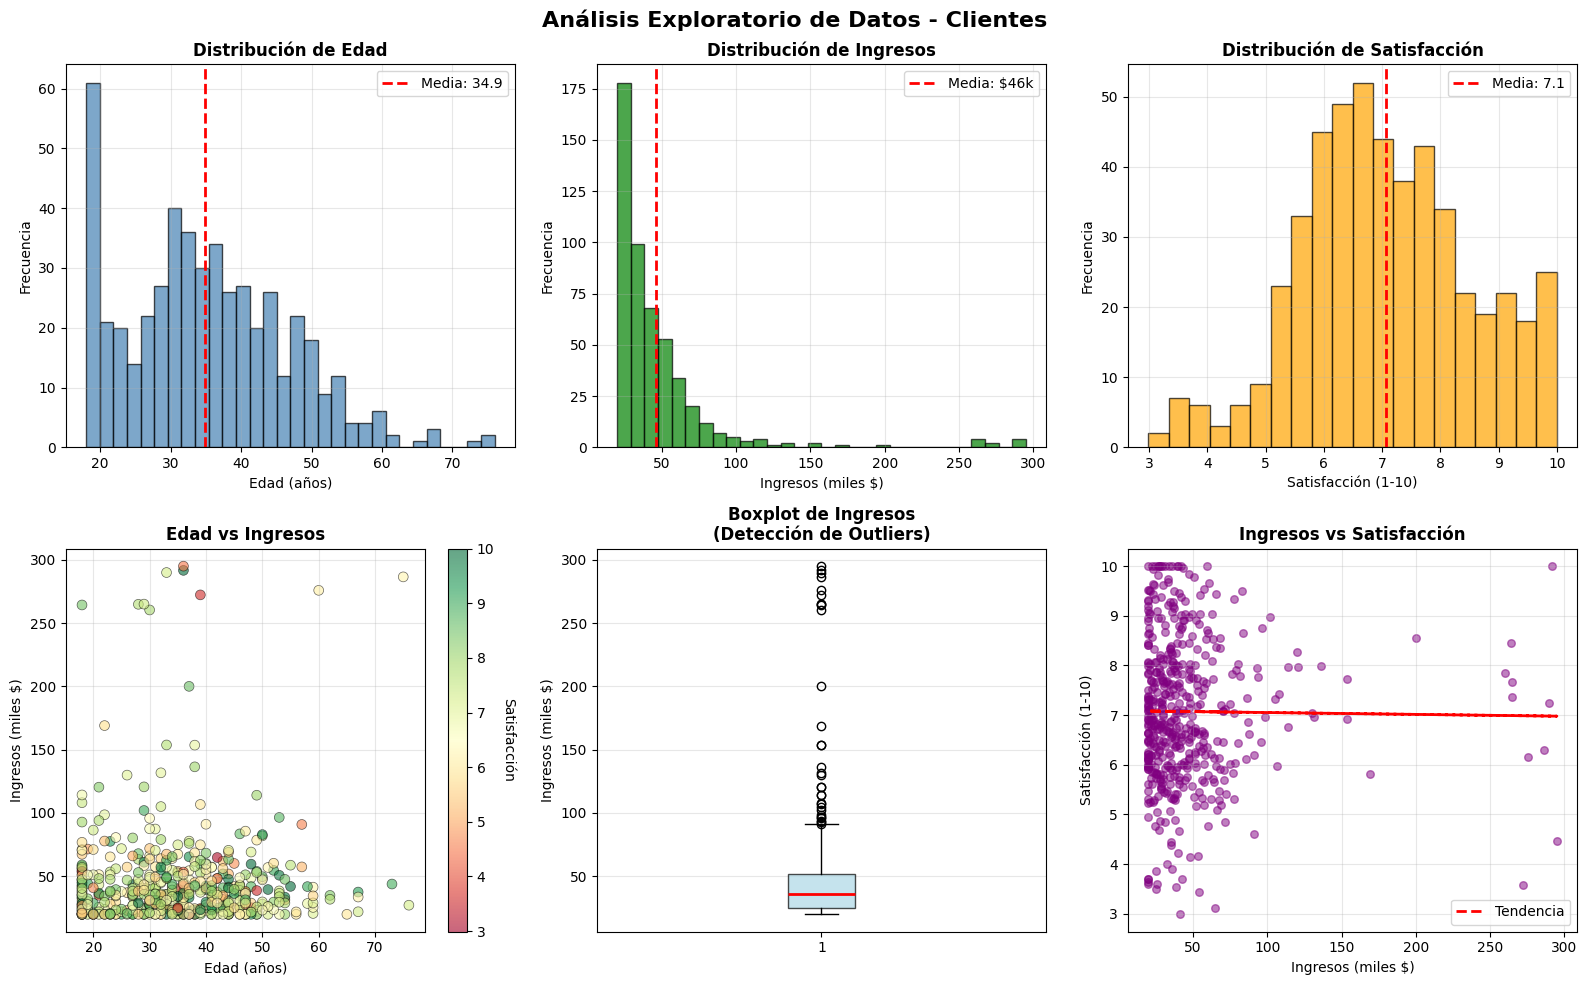

In [18]:
# Crear EDA con GridSpec
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1, 1, 1])
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Análisis Exploratorio de Datos - Clientes', fontsize=16, fontweight='bold')

# Gráfico 1: Distribución de Edad
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(edad, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(edad.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {edad.mean():.1f}')
ax1.set_title('Distribución de Edad', fontweight='bold')
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Frecuencia')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de Ingresos
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(ingresos/1000, bins=30, color='green', edgecolor='black', alpha=0.7)
ax2.axvline(ingresos.mean()/1000, color='red', linestyle='--', linewidth=2,
            label=f'Media: ${ingresos.mean()/1000:.0f}k')
ax2.set_title('Distribución de Ingresos', fontweight='bold')
ax2.set_xlabel('Ingresos (miles $)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Distribución de Satisfacción
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(satisfaccion, bins=20, color='orange', edgecolor='black', alpha=0.7)
ax3.axvline(satisfaccion.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {satisfaccion.mean():.1f}')
ax3.set_title('Distribución de Satisfacción', fontweight='bold')
ax3.set_xlabel('Satisfacción (1-10)')
ax3.set_ylabel('Frecuencia')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Edad vs Ingresos
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(edad, ingresos/1000, c=satisfaccion, cmap='RdYlGn',
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax4.set_title('Edad vs Ingresos', fontweight='bold')
ax4.set_xlabel('Edad (años)')
ax4.set_ylabel('Ingresos (miles $)')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Satisfacción', rotation=270, labelpad=15)

# Gráfico 5: Boxplot de Ingresos
ax5 = fig.add_subplot(gs[1, 1])
ax5.boxplot(ingresos/1000, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax5.set_title('Boxplot de Ingresos\n(Detección de Outliers)', fontweight='bold')
ax5.set_ylabel('Ingresos (miles $)')
ax5.grid(True, alpha=0.3, axis='y')

# Gráfico 6: Ingresos vs Satisfacción
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(ingresos/1000, satisfaccion, alpha=0.5, color='purple', s=30)
# Añadir línea de tendencia
z = np.polyfit(ingresos, satisfaccion, 1)
p = np.poly1d(z)
ax6.plot(ingresos/1000, p(ingresos), "r--", linewidth=2, label='Tendencia')
ax6.set_title('Ingresos vs Satisfacción', fontweight='bold')
ax6.set_xlabel('Ingresos (miles $)')
ax6.set_ylabel('Satisfacción (1-10)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Insights del Caso 2:**

✅ **Distribuciones:** Histogramas muestran si los datos son normales, sesgados o tienen outliers
✅ **Correlaciones:** Scatter plots revelan relaciones entre variables
✅ **Outliers:** Boxplot identifica valores atípicos en ingresos
✅ **Tendencias:** Línea de tendencia muestra relación ingresos-satisfacción

**Observaciones clave:**
- La edad sigue una distribución aproximadamente normal
- Los ingresos tienen outliers significativos (>$250k)
- Existe una leve correlación positiva entre ingresos y satisfacción
- La satisfacción promedio es de 7/10

**Próximos pasos:** Investigar outliers de ingresos y analizar por qué algunos clientes de altos ingresos tienen baja satisfacción.

## Mejores Prácticas

### ✅ DO (Hacer)

1. **Usar `tight_layout()`:** Evita superposición de elementos
2. **Títulos descriptivos:** Cada subplot debe tener un título claro
3. **Colores coherentes:** Usa paletas consistentes
4. **Tamaños apropiados:** `figsize=(14, 10)` o mayor para dashboards
5. **Etiquetas en ejes:** Siempre incluye xlabel e ylabel
6. **Grid sutil:** `alpha=0.3` para cuadrícula no intrusiva

### ❌ DON'T (Evitar)

1. **Demasiados subplots:** Máximo 6-9 por figura
2. **Textos pequeños:** Usar `fontsize` adecuado
3. **Colores chillones:** Preferir paletas profesionales
4. **Gráficos sin contexto:** Siempre añadir títulos
5. **Olvida `tight_layout()`:** Causa superposiciones

## Comparación: subplot vs GridSpec

### Ejemplo rápido de diferencias

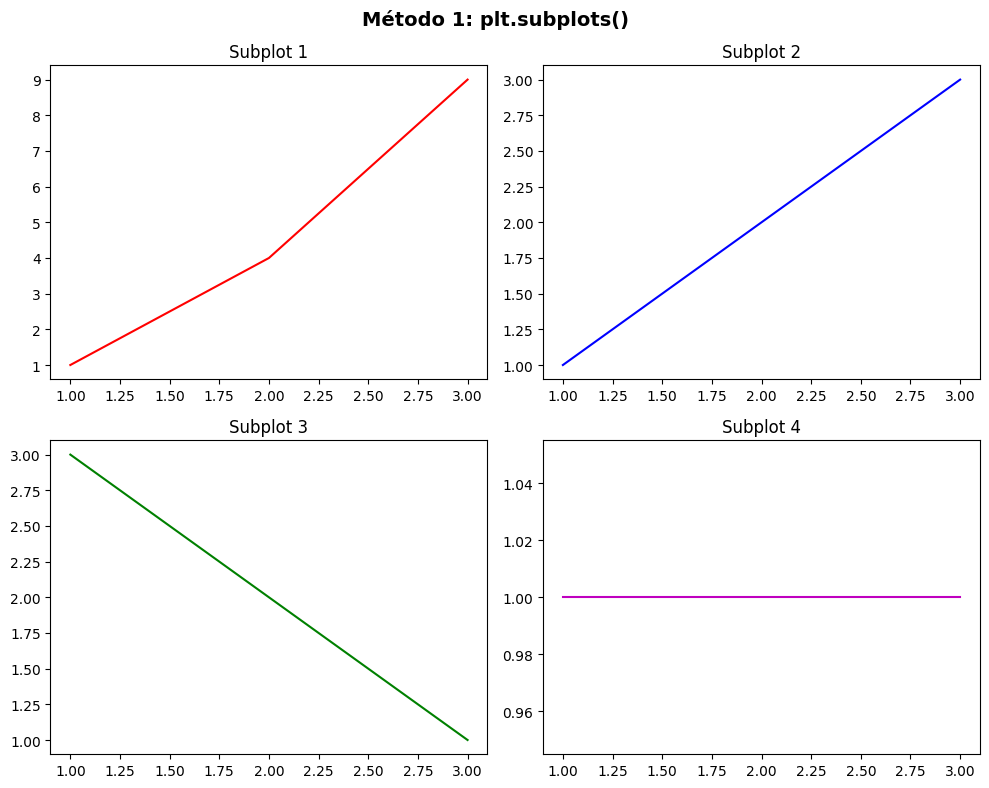

In [19]:
# Método 1: plt.subplots() - Simple pero limitado
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Método 1: plt.subplots()', fontsize=14, fontweight='bold')

axes[0, 0].plot([1, 2, 3], [1, 4, 9], 'r-')
axes[0, 0].set_title('Subplot 1')

axes[0, 1].plot([1, 2, 3], [1, 2, 3], 'b-')
axes[0, 1].set_title('Subplot 2')

axes[1, 0].plot([1, 2, 3], [3, 2, 1], 'g-')
axes[1, 0].set_title('Subplot 3')

axes[1, 1].plot([1, 2, 3], [1, 1, 1], 'm-')
axes[1, 1].set_title('Subplot 4')

plt.tight_layout()
plt.show()

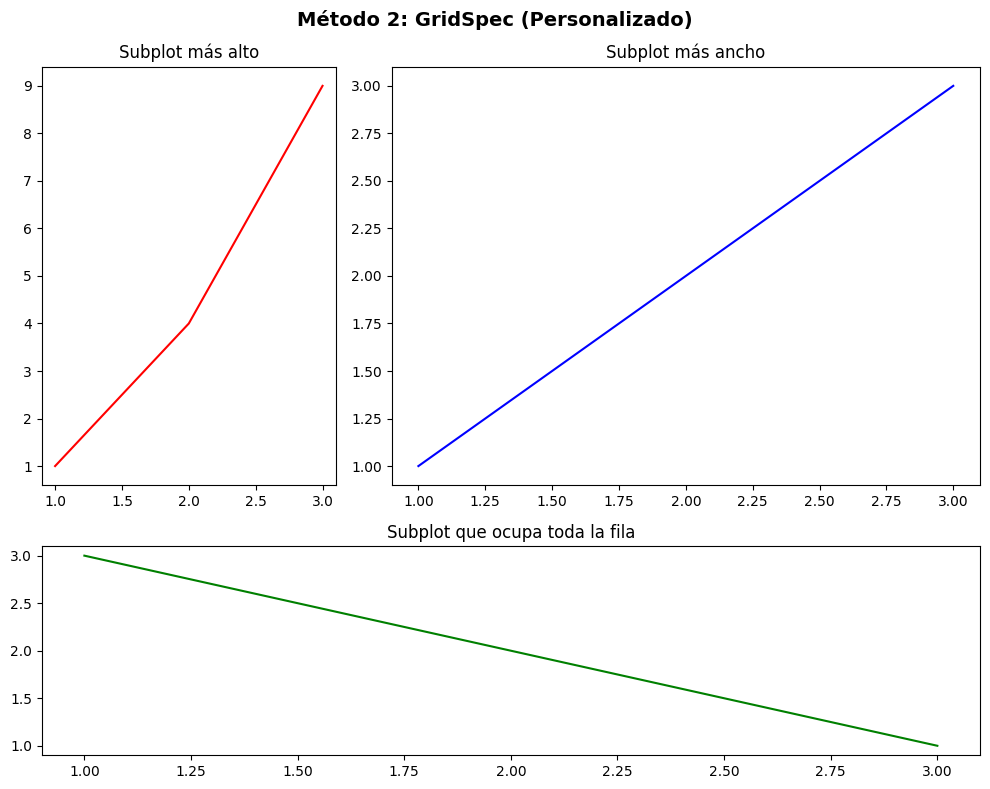

In [20]:
# Método 2: GridSpec - Flexible y personalizado
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1], width_ratios=[1, 2])
fig = plt.figure(figsize=(10, 8))
fig.suptitle('Método 2: GridSpec (Personalizado)', fontsize=14, fontweight='bold')

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([1, 2, 3], [1, 4, 9], 'r-')
ax1.set_title('Subplot más alto')

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot([1, 2, 3], [1, 2, 3], 'b-')
ax2.set_title('Subplot más ancho')

ax3 = fig.add_subplot(gs[1, :])
ax3.plot([1, 2, 3], [3, 2, 1], 'g-')
ax3.set_title('Subplot que ocupa toda la fila')

plt.tight_layout()
plt.show()

**Conclusión:**
- Usa `plt.subplots()` para layouts simples y uniformes
- Usa `GridSpec` cuando necesites layouts personalizados y profesionales

## Recursos Adicionales

### Documentación Oficial
- [Matplotlib GridSpec](https://matplotlib.org/stable/api/_as_gen/matplotlib.gridspec.GridSpec.html)
- [Matplotlib Subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
- [Tight Layout](https://matplotlib.org/stable/tutorials/intermediate/tight_layout_guide.html)

### Archivos Relacionados
- `24_mpl_creacion_graficos_combinados_gridspec.ipynb` - Este notebook
- Tema anterior: Series temporales
- Próximo tema: Personalización avanzada de gráficos

### Conexión con el Proyecto Final
Los dashboards con GridSpec serán esenciales para presentar el análisis completo del "Customer Experience Analyzer", mostrando múltiples métricas CSAT en una sola vista ejecutiva.